# ViT-B16 Evaluation — Fidelity Scoring + Pointing Game
Run cells 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 in order.

Computes fidelity (IoU/Dice) and pointing game scores for:
- `vit_b16` / `attention_rollout`

Requires ViT heatmaps at:
`results/heatmaps/vit_b16/attention_rollout/`

## What these metrics measure

**Fidelity (IoU/Dice — Otsu variant):**
- Binarizes the attention heatmap using Otsu's method (data-driven threshold)
- Computes IoU and Dice between the binarized heatmap and ground-truth lesion masks
- Stratified by predicted grade × lesion type (MA, HE, EX, SE)
- Uses the same Otsu method as GradCAM/LIME/SHAP fidelity scores — directly comparable

**Pointing game:**
- After FOV masking and renormalization, finds the peak attention pixel (argmax)
- Hit = 1 if that pixel falls inside any ground-truth lesion mask, 0 otherwise
- NaN = lesion absent for that image (excluded, not counted as miss)
- Stratified by predicted grade × lesion type

## Output files saved to `results/scores/`
- `fidelity_scores_vit_b16_attention_rollout.csv`
- `pointing_game_vit_b16_attention_rollout.csv`

## Note
ViT predicted grades are sourced from `aopc_vit_b16_attention_rollout.csv`
A separate `vit_b16_predictions.csv` is created by this notebook —
the shared `predictions.csv` is not modified.

In [31]:
# ==== CELL 1 — Paths + sys.path setup (VS Code local version) ====
import sys
from pathlib import Path
 
# Local paths — Drive for Desktop already mounts the shared folder
PROJECT_ROOT = Path(r"G:\.shortcut-targets-by-id\1pDMOv8oZXnC8AiUIUxcu0OaihyxWM146\diabetic-retinopathy-xai")
EVAL_DIR     = Path(r"C:\Users\Shravni Joshi\Documents\Diabetic Retinopathy\diabetic-retinopathy-xai\eval")
REPO_ROOT    = Path(r"C:\Users\Shravni Joshi\Documents\Diabetic Retinopathy\diabetic-retinopathy-xai")
 
# Add eval/ to path so the scripts can import each other (roi_mask_utils, fidelity_scoring etc.)
if str(EVAL_DIR) not in sys.path:
    sys.path.insert(0, str(EVAL_DIR))
 
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"EVAL_DIR: {EVAL_DIR}")
print(f"PROJECT_ROOT exists: {PROJECT_ROOT.exists()}")
print(f"EVAL_DIR exists: {EVAL_DIR.exists()}")
 

PROJECT_ROOT: G:\.shortcut-targets-by-id\1pDMOv8oZXnC8AiUIUxcu0OaihyxWM146\diabetic-retinopathy-xai
EVAL_DIR: C:\Users\Shravni Joshi\Documents\Diabetic Retinopathy\diabetic-retinopathy-xai\eval
PROJECT_ROOT exists: True
EVAL_DIR exists: True


In [32]:
 
# ==== CELL 2 — Imports ====
import os
import json
import numpy as np
import pandas as pd
 
from fidelity_scoring_otsu import run_fidelity_scoring
from pointing_game import run_pointing_game
 
print("Imports OK.")

# Override hardcoded Colab paths in the eval scripts
import fidelity_scoring_otsu as fso
import fidelity_scoring as fs
import roi_mask_utils as rmu

_DATA_ROOT  = str(PROJECT_ROOT / "data" / "IDRiD")
_ORIG_IMG   = str(PROJECT_ROOT / "data" / "IDRiD" / "segmentation" / "images" / "test")
_MASK_ROOT  = str(PROJECT_ROOT / "data" / "IDRiD" / "segmentation" / "masks" / "test")
_RESULTS    = str(PROJECT_ROOT / "results")

for mod in [fso, fs]:
    mod.PROJECT_ROOT = str(PROJECT_ROOT)
    mod.ORIG_IMG_DIR = _ORIG_IMG
    mod.MASK_ROOT    = _MASK_ROOT
    mod.RESULTS_DIR  = _RESULTS

import pointing_game as pg
pg.PROJECT_ROOT = str(PROJECT_ROOT)
pg.ORIG_IMG_DIR = _ORIG_IMG
pg.MASK_ROOT    = _MASK_ROOT
pg.RESULTS_DIR  = _RESULTS

Imports OK.


In [33]:
 
# ==== CELL 3 — Build separate vit_b16_predictions.csv (does NOT touch shared file) ====
# Extracts predicted_grade from Tanvi's AOPC file + true_grade from shared predictions.csv
# Saves as a SEPARATE file used only by this notebook.
 
aopc_path       = PROJECT_ROOT / "results" / "scores" / "aopc_vit_b16_attention_rollout.csv"
shared_pred_path = PROJECT_ROOT / "results" / "heatmaps" / "predictions.csv"
vit_pred_path   = PROJECT_ROOT / "results" / "heatmaps" / "vit_b16_predictions.csv"
 
print(f"AOPC file exists: {aopc_path.exists()}")
print(f"Shared predictions.csv exists: {shared_pred_path.exists()}")
 
aopc_df = pd.read_csv(aopc_path)
shared_preds = pd.read_csv(shared_pred_path)
 
true_grade_lookup = (
    shared_preds.drop_duplicates("image_id")
    .set_index("image_id")["true_grade"]
    .to_dict()
)
 
vit_rows = []
for _, row in aopc_df.iterrows():
    image_id = row["image_id"]
    vit_rows.append({
        "image_id": image_id,
        "model": "vit_b16",
        "predicted_grade": int(row["predicted_grade"]),
        "true_grade": int(true_grade_lookup.get(image_id, -1)),
        "confidence": float("nan"),
    })
 
vit_preds_df = pd.DataFrame(vit_rows)
vit_preds_df.to_csv(vit_pred_path, index=False)
print(f"\nSaved: {vit_pred_path}")
print(f"Rows: {len(vit_preds_df)}")
print(vit_preds_df.head())
print("\nShared predictions.csv is UNCHANGED.")

AOPC file exists: True
Shared predictions.csv exists: True

Saved: G:\.shortcut-targets-by-id\1pDMOv8oZXnC8AiUIUxcu0OaihyxWM146\diabetic-retinopathy-xai\results\heatmaps\vit_b16_predictions.csv
Rows: 27
   image_id    model  predicted_grade  true_grade  confidence
0  IDRiD_55  vit_b16                2           3         NaN
1  IDRiD_56  vit_b16                1           2         NaN
2  IDRiD_57  vit_b16                4           3         NaN
3  IDRiD_58  vit_b16                0           2         NaN
4  IDRiD_59  vit_b16                2           2         NaN

Shared predictions.csv is UNCHANGED.


In [34]:
# ==== CELL 4 — Constants ====
MODEL_NAME  = "vit_b16"
METHOD_NAME = "attention_rollout"
 
HEATMAP_FOLDER      = str(PROJECT_ROOT / "results" / "heatmaps" / MODEL_NAME / METHOD_NAME)
VIT_PREDICTIONS_CSV = str(vit_pred_path)
RESULTS_DIR         = str(PROJECT_ROOT / "results" / "scores")
 
FIDELITY_SAVE_PATH      = os.path.join(RESULTS_DIR, f"fidelity_scores_{MODEL_NAME}_{METHOD_NAME}.csv")
POINTING_GAME_SAVE_PATH = os.path.join(RESULTS_DIR, f"pointing_game_{MODEL_NAME}_{METHOD_NAME}.csv")
 
print(f"Model:            {MODEL_NAME}")
print(f"Method:           {METHOD_NAME}")
print(f"Heatmap folder:   {HEATMAP_FOLDER}")
print(f"ViT predictions:  {VIT_PREDICTIONS_CSV}")
print(f"Results dir:      {RESULTS_DIR}")


Model:            vit_b16
Method:           attention_rollout
Heatmap folder:   G:\.shortcut-targets-by-id\1pDMOv8oZXnC8AiUIUxcu0OaihyxWM146\diabetic-retinopathy-xai\results\heatmaps\vit_b16\attention_rollout
ViT predictions:  G:\.shortcut-targets-by-id\1pDMOv8oZXnC8AiUIUxcu0OaihyxWM146\diabetic-retinopathy-xai\results\heatmaps\vit_b16_predictions.csv
Results dir:      G:\.shortcut-targets-by-id\1pDMOv8oZXnC8AiUIUxcu0OaihyxWM146\diabetic-retinopathy-xai\results\scores


In [35]:
# ==== CELL 5 — Sanity checks ====
print("=== Sanity checks ===\n")
 
# Heatmap folder
if not os.path.exists(HEATMAP_FOLDER):
    print(f"ERROR: Heatmap folder missing: {HEATMAP_FOLDER}")
else:
    npy_files = [f for f in os.listdir(HEATMAP_FOLDER) if f.endswith(".npy")]
    print(f"Heatmap folder OK. Found {len(npy_files)} .npy files.")
    print(f"First few: {npy_files[:5]}")
 
# ViT predictions file
if not os.path.exists(VIT_PREDICTIONS_CSV):
    print(f"\nERROR: vit_b16_predictions.csv missing -- run Cell 3 first")
else:
    vit_check = pd.read_csv(VIT_PREDICTIONS_CSV)
    print(f"\nvit_b16_predictions.csv OK: {len(vit_check)} rows")
    print(vit_check.head())
 
# test_image_ids.json
test_ids_path = str(REPO_ROOT / "test_image_ids.json")
if os.path.exists(test_ids_path):
    with open(test_ids_path) as f:
        test_ids = json.load(f)
    print(f"\ntest_image_ids.json OK: {len(test_ids)} IDs")
else:
    print(f"\nERROR: test_image_ids.json not found at {test_ids_path}")

=== Sanity checks ===

Heatmap folder OK. Found 27 .npy files.
First few: ['vit_b16_attention_rollout_IDRiD_55.npy', 'vit_b16_attention_rollout_IDRiD_56.npy', 'vit_b16_attention_rollout_IDRiD_57.npy', 'vit_b16_attention_rollout_IDRiD_58.npy', 'vit_b16_attention_rollout_IDRiD_59.npy']

vit_b16_predictions.csv OK: 27 rows
   image_id    model  predicted_grade  true_grade  confidence
0  IDRiD_55  vit_b16                2           3         NaN
1  IDRiD_56  vit_b16                1           2         NaN
2  IDRiD_57  vit_b16                4           3         NaN
3  IDRiD_58  vit_b16                0           2         NaN
4  IDRiD_59  vit_b16                2           2         NaN

test_image_ids.json OK: 27 IDs


In [36]:
# ==== CELL 6 — Run Fidelity Scoring (Otsu variant) ====
print("Running fidelity scoring (Otsu)...")
print("=" * 60)
 
fidelity_df = run_fidelity_scoring(
    heatmap_folder=HEATMAP_FOLDER,
    model_name=MODEL_NAME,
    method_name=METHOD_NAME,
    predictions_csv=VIT_PREDICTIONS_CSV,
    save_path=FIDELITY_SAVE_PATH,
)
 
print(f"\nFidelity scoring done. Rows scored: {len(fidelity_df)}")
print(f"\nSummary by lesion type:")
print(fidelity_df.groupby("lesion_type")[["iou", "dice"]].agg(["mean", "std", "count"]).round(4))

Running fidelity scoring (Otsu)...
Scored 95 (image, lesion_type) pairs for model=vit_b16, method=attention_rollout
Saved: G:\.shortcut-targets-by-id\1pDMOv8oZXnC8AiUIUxcu0OaihyxWM146\diabetic-retinopathy-xai\results\scores\fidelity_scores_vit_b16_attention_rollout.csv

Fidelity scoring done. Rows scored: 95

Summary by lesion type:
                iou                  dice              
               mean     std count    mean     std count
lesion_type                                            
EX           0.0231  0.0383    27  0.0429  0.0661    27
HE           0.0133  0.0213    27  0.0254  0.0388    27
MA           0.0017  0.0014    27  0.0034  0.0028    27
SE           0.0048  0.0058    14  0.0095  0.0114    14


In [37]:
# ==== CELL 7 — Run Pointing Game ====
print("Running pointing game...")
print("=" * 60)
 
pointing_df = run_pointing_game(
    heatmap_folder=HEATMAP_FOLDER,
    model_name=MODEL_NAME,
    method_name=METHOD_NAME,
    predictions_csv=VIT_PREDICTIONS_CSV,
    save_path=POINTING_GAME_SAVE_PATH,
)
 
print(f"\nPointing game done. Rows scored: {len(pointing_df)}")
print(f"Overall accuracy: {pointing_df['hit'].mean():.3f}")
print(f"\nAccuracy by lesion type:")
print(pointing_df.groupby("lesion_type")["hit"].agg(["mean", "count"]).round(4))

Running pointing game...
Pointing game: 0/95 hits for model=vit_b16, method=attention_rollout (accuracy=0.000)
Saved: G:\.shortcut-targets-by-id\1pDMOv8oZXnC8AiUIUxcu0OaihyxWM146\diabetic-retinopathy-xai\results\scores\pointing_game_vit_b16_attention_rollout.csv

Pointing game done. Rows scored: 95
Overall accuracy: 0.000

Accuracy by lesion type:
             mean  count
lesion_type             
EX            0.0     27
HE            0.0     27
MA            0.0     27
SE            0.0     14


In [38]:
# Debug — check if heatmap shape matches mask shape for pointing game
# 0/95 hits is suspicious -- likely a resolution mismatch

import cv2
import numpy as np
import glob
import os

SAMPLE_ID = "IDRiD_55"

# Load one heatmap
heatmap_path = os.path.join(HEATMAP_FOLDER, f"vit_b16_attention_rollout_{SAMPLE_ID}.npy")
heatmap = np.load(heatmap_path)
print(f"Heatmap shape: {heatmap.shape}")

# Load the original image (used for FOV mask)
orig_img_path = str(PROJECT_ROOT / "data" / "IDRiD" / "segmentation" / "images" / "test" / f"{SAMPLE_ID}.jpg")
print(f"Original image exists: {os.path.exists(orig_img_path)}")
orig_img = cv2.imread(orig_img_path)
print(f"Original image shape: {orig_img.shape}")  # (H, W, 3)

# Load one lesion mask (EX -- most common, most likely to have a hit)
mask_dir = str(PROJECT_ROOT / "data" / "IDRiD" / "segmentation" / "masks" / "test" / "3. Hard Exudates")
mask_matches = glob.glob(os.path.join(mask_dir, f"{SAMPLE_ID}_*"))
print(f"\nMask matches: {mask_matches}")
if mask_matches:
    mask = cv2.imread(mask_matches[0], cv2.IMREAD_GRAYSCALE)
    print(f"Mask shape (raw): {mask.shape}")
    print(f"Mask nonzero pixels: {(mask > 0).sum()}")

# The pointing game checks gt_mask at the heatmap's argmax coordinate
# If heatmap shape != mask shape, the coordinate is meaningless
print(f"\nHeatmap shape == original image shape: {heatmap.shape == orig_img.shape[:2]}")
print(f"Heatmap shape == mask shape: {heatmap.shape == mask.shape if mask_matches else 'N/A'}")

# Where is the argmax?
argmax = np.unravel_index(np.argmax(heatmap), heatmap.shape)
print(f"\nHeatmap argmax (peak pixel): {argmax}")
print(f"Heatmap value at argmax: {heatmap[argmax]:.4f}")

Heatmap shape: (2848, 4288)
Original image exists: True
Original image shape: (2848, 4288, 3)

Mask matches: ['G:\\.shortcut-targets-by-id\\1pDMOv8oZXnC8AiUIUxcu0OaihyxWM146\\diabetic-retinopathy-xai\\data\\IDRiD\\segmentation\\masks\\test\\3. Hard Exudates\\IDRiD_55_EX.tif']
Mask shape (raw): (2848, 4288)
Mask nonzero pixels: 497671

Heatmap shape == original image shape: True
Heatmap shape == mask shape: True

Heatmap argmax (peak pixel): (np.int64(1728), np.int64(765))
Heatmap value at argmax: 1.0000


In [39]:
# Quick check -- is the argmax pixel inside the EX mask?
argmax_r, argmax_c = 1728, 765
print(f"Mask value at argmax ({argmax_r}, {argmax_c}): {mask[argmax_r, argmax_c]}")
print(f"Is hit: {mask[argmax_r, argmax_c] > 0}")

Mask value at argmax (1728, 765): 0
Is hit: False


In [40]:
from roi_mask_utils import get_fundus_mask, apply_fov_mask_and_renormalize

fov_mask = get_fundus_mask(orig_img_path)
print(f"FOV mask shape: {fov_mask.shape}")
print(f"FOV mask nonzero pixels: {fov_mask.sum()}")

heatmap_clean = apply_fov_mask_and_renormalize(heatmap, fov_mask)
print(f"Heatmap clean shape: {heatmap_clean.shape}")
print(f"Heatmap clean max: {heatmap_clean.max():.4f}")

argmax_clean = np.unravel_index(np.argmax(heatmap_clean), heatmap_clean.shape)
print(f"Argmax AFTER FOV masking: {argmax_clean}")
print(f"Mask value at clean argmax: {mask[argmax_clean[0], argmax_clean[1]]}")
print(f"Is hit after FOV masking: {mask[argmax_clean[0], argmax_clean[1]] > 0}")

FOV mask shape: (2848, 4288)
FOV mask nonzero pixels: 8435017.0
Heatmap clean shape: (2848, 4288)
Heatmap clean max: 1.0000
Argmax AFTER FOV masking: (np.int64(1728), np.int64(765))
Mask value at clean argmax: 0
Is hit after FOV masking: False


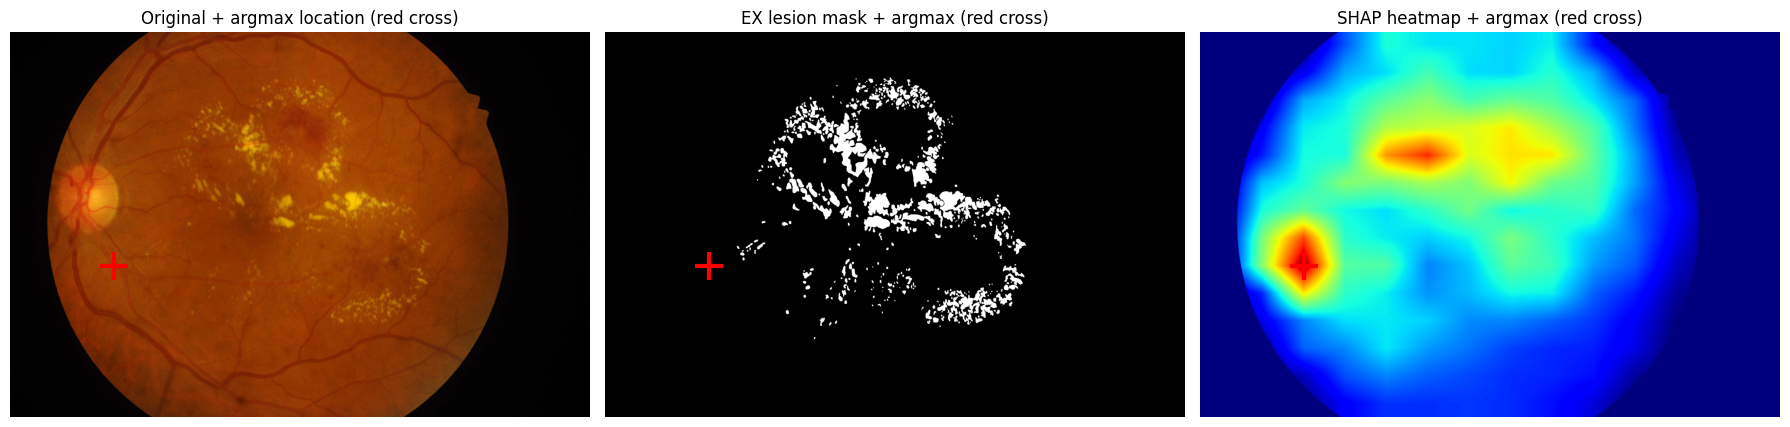

In [41]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage

orig = PILImage.open(orig_img_path).convert("RGB")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(orig)
axes[0].plot(765, 1728, 'r+', markersize=20, markeredgewidth=3)
axes[0].set_title("Original + argmax location (red cross)")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].plot(765, 1728, 'r+', markersize=20, markeredgewidth=3)
axes[1].set_title("EX lesion mask + argmax (red cross)")
axes[1].axis("off")

axes[2].imshow(heatmap_clean, cmap="jet")
axes[2].plot(765, 1728, 'r+', markersize=20, markeredgewidth=3)
axes[2].set_title("SHAP heatmap + argmax (red cross)")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("pointing_game_debug.png", dpi=80, bbox_inches="tight")
plt.show()

In [42]:
# ==== CELL 8 — Stratified summary ====
print("=" * 60)
print("STRATIFIED SUMMARY")
print("=" * 60)
 
print("\nFidelity (IoU/Dice) by predicted_grade x lesion_type:")
print(
    fidelity_df.groupby(["predicted_grade", "lesion_type"])[["iou", "dice"]]
    .agg(["mean", "std", "count"])
    .round(4)
)
 
print("\nPointing game by predicted_grade x lesion_type:")
print(
    pointing_df.groupby(["predicted_grade", "lesion_type"])["hit"]
    .agg(["mean", "count"])
    .round(4)
)
 
print(f"\nFiles saved:")
print(f"  {FIDELITY_SAVE_PATH}")
print(f"  {POINTING_GAME_SAVE_PATH}")

STRATIFIED SUMMARY

Fidelity (IoU/Dice) by predicted_grade x lesion_type:
                                iou                  dice              
                               mean     std count    mean     std count
predicted_grade lesion_type                                            
0               EX           0.0259  0.0333     5  0.0489  0.0610     5
                HE           0.0062  0.0078     5  0.0121  0.0153     5
                MA           0.0015  0.0025     5  0.0031  0.0050     5
                SE           0.0031     NaN     1  0.0063     NaN     1
1               EX           0.0102  0.0096     7  0.0201  0.0187     7
                HE           0.0111  0.0092     7  0.0218  0.0178     7
                MA           0.0020  0.0013     7  0.0041  0.0025     7
                SE           0.0060  0.0051     4  0.0118  0.0100     4
2               EX           0.0364  0.0570    10  0.0654  0.0968    10
                HE           0.0103  0.0097    10  0.0202  0.0